<a href="https://colab.research.google.com/github/boshetunmay1/paris-real-estate-analysis/blob/main/kursovaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЗАГРУЗКА ДАННЫХ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_path = '/content/drive/MyDrive/ParisHousing.csv'

df = pd.read_csv(file_path)
df = df.iloc[350:451]

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

# ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ

## Характеристики выборки

In [ ]:
print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())
info_df = pd.DataFrame({
    'Тип данных':      df.dtypes,
    'Пропусков': df.isnull().sum(),
    'Пропусков %':   (df.isnull().sum() / len(df) * 100).round(2)
})
display(info_df)
display(df.describe().T.round(2))

Размер датасета: 101 строк × 17 столбцов


,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
350,19649,11,0,1,83,87255,4,4,1999,1,0,595,6282,795,1,2,1970018.9
351,141,16,0,1,58,42248,5,4,1997,1,0,3411,8985,213,0,4,22670.7
352,22821,64,1,1,14,66304,9,8,1993,1,1,2060,103,491,1,2,2289134.3
353,533,76,1,1,55,94923,6,8,2021,1,1,654,3585,301,0,9,65465.1
354,67020,71,1,1,38,64361,4,7,2015,0,0,3647,997,640,0,1,6711051.5


,Тип данных,Пропусков,Пропусков %
squareMeters,int64,0,0.0
numberOfRooms,int64,0,0.0
hasYard,int64,0,0.0
hasPool,int64,0,0.0
floors,int64,0,0.0
cityCode,int64,0,0.0
cityPartRange,int64,0,0.0
numPrevOwners,int64,0,0.0
made,int64,0,0.0
isNewBuilt,int64,0,0.0


,count,mean,std,min,25%,50%,75%,max
squareMeters,101.0,44216.89,29579.24,141.0,18926.0,38700.0,70763.0,99767.0
numberOfRooms,101.0,49.75,29.52,1.0,25.0,51.0,71.0,100.0
hasYard,101.0,0.52,0.50,0.0,0.0,1.0,1.0,1.0
hasPool,101.0,0.53,0.50,0.0,0.0,1.0,1.0,1.0
floors,101.0,53.58,29.58,1.0,32.0,54.0,80.0,99.0
cityCode,101.0,52864.53,29261.99,3.0,27552.0,50519.0,81044.0,99953.0
cityPartRange,101.0,5.98,2.91,1.0,4.0,7.0,8.0,10.0
numPrevOwners,101.0,6.22,2.43,1.0,4.0,7.0,8.0,10.0
made,101.0,2004.80,9.64,1990.0,1996.0,2004.0,2013.0,2021.0
isNewBuilt,101.0,0.49,0.50,0.0,0.0,0.0,1.0,1.0


## Предварительаня обработка данных

In [ ]:
print("Пропуски по каждой колонке:")
missing = df.isnull().sum().rename('Пропусков').to_frame()
missing['%'] = (missing['Пропусков'] / len(df) * 100).round(2)
display(missing)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f"\nДо удаления строк с пропусками: {rows_before}")
print(f"После удаления: {rows_after}")
print(f"Удалено строк: {rows_before - rows_after}")

Пропуски по каждой колонке:


,Пропусков,%
squareMeters,0,0.0
numberOfRooms,0,0.0
hasYard,0,0.0
hasPool,0,0.0
floors,0,0.0
cityCode,0,0.0
cityPartRange,0,0.0
numPrevOwners,0,0.0
made,0,0.0
isNewBuilt,0,0.0



До удаления строк с пропусками: 101
После удаления: 101
Удалено строк: 0


## Выявление выбросов

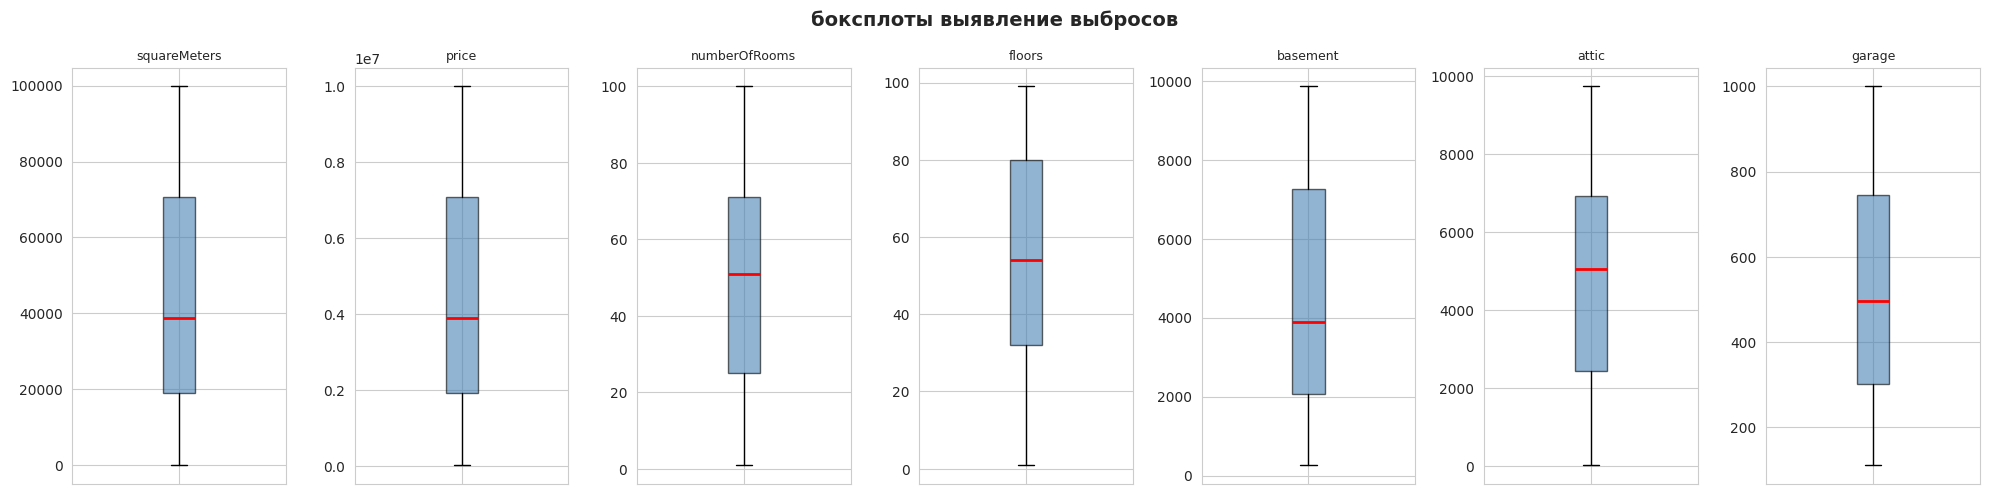

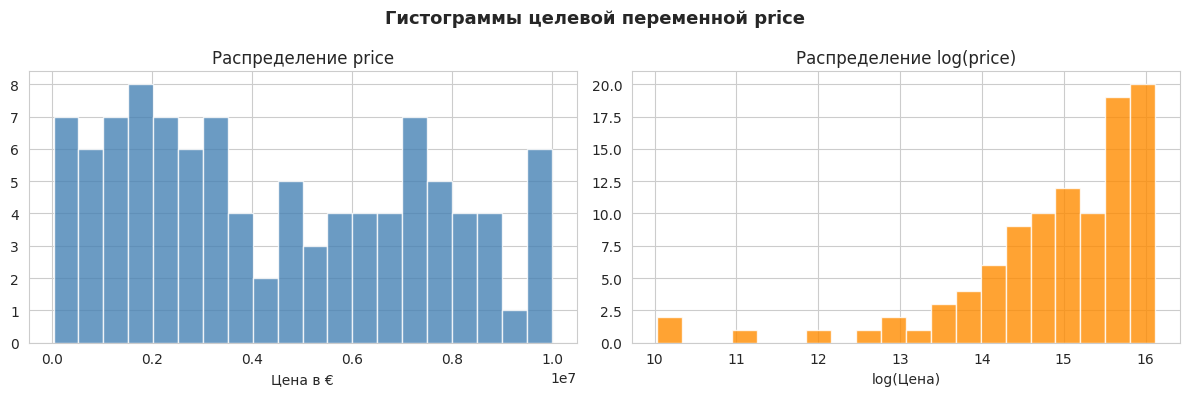

Количество выбросов по IQR
  squareMeters        : 0 выбросов
  price               : 0 выбросов
  numberOfRooms       : 0 выбросов
  floors              : 0 выбросов
  basement            : 0 выбросов
  attic               : 0 выбросов
  garage              : 0 выбросов


In [7]:
key_cols = ['squareMeters', 'price', 'numberOfRooms',
            'floors', 'basement', 'attic', 'garage']

#боксплоты
fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 5))
fig.suptitle('боксплоты выявление выбросов',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

#гистограммы для price
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Распределение price')
plt.xlabel('Цена в €')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['price']), bins=20, color='darkorange',
         edgecolor='white', alpha=0.8)
plt.title('Распределение log(price)')
plt.xlabel('log(Цена)')

plt.suptitle('Гистограммы целевой переменной price', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

#подсчёт выбросов по IQR
print("Количество выбросов по IQR")
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<20}: {n_out} выбросов")

## Стандартизация данных


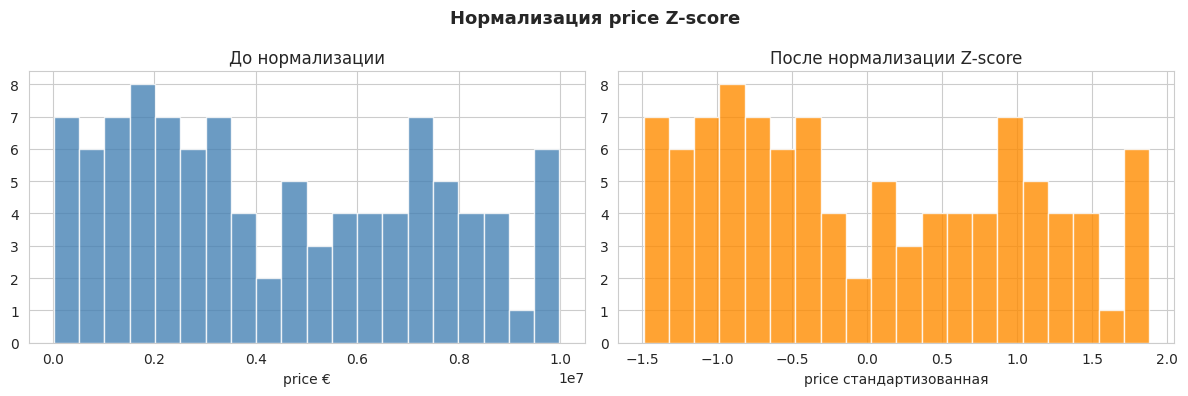

Статистика price_scaled после стандартизации:
count    101.0000
mean      -0.0000
std        1.0000
min       -1.4896
25%       -0.8521
50%       -0.1854
75%        0.8971
max        1.8788
Name: price_scaled, dtype: float64


In [9]:
cols_to_scale = ['squareMeters', 'price', 'numberOfRooms',
                 'basement', 'attic', 'garage', 'floors']

df_normalized = df.copy()

for col in cols_to_scale:
    mean = df[col].mean()
    std  = df[col].std()
    df_normalized[col + '_scaled'] = (df[col] - mean) / std

#сравнение до/после для price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Нормализация price Z-score',
             fontsize=13, fontweight='bold')

axes[0].hist(df['price'], bins=20, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_title('До нормализации')
axes[0].set_xlabel('price €')

axes[1].hist(df_normalized['price_scaled'], bins=20,
             color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('После нормализации Z-score')
axes[1].set_xlabel('price стандартизованная')

plt.tight_layout()
plt.show()

print("Статистика price_scaled после стандартизации:")
print(df_normalized['price_scaled'].describe().round(4))